# Analiza zbioru LandCover.ai

In [ ]:
import sys

sys.path.append("../")

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import pandas as pd

from torch_datasets.landcover_dataset import LandcoverDataset

In [4]:
DATA_DIR = Path("../data/landcover.ai.v1")

In [73]:
data_val = LandcoverDataset(image_dir=DATA_DIR / "output",
                                          split_file=DATA_DIR / "val.txt",
                                          return_meta=True)
data_train = LandcoverDataset(image_dir=DATA_DIR / "output",
                                          split_file=DATA_DIR / "train.txt",
                                          return_meta=True)
data_test = LandcoverDataset(image_dir=DATA_DIR / "output",
                                          split_file=DATA_DIR / "test.txt",
                                          return_meta=True)

In [ ]:
data = data_val # ZMIENIĆ NA TRAIN

np.random.seed(1)
sample_size = 500 # ZWIĘKSZYĆ

rng_indices = np.random.randint(0, len(data), sample_size)
sample_train = [data_train[i] for i in rng_indices]
sample_val = [data_val[i] for i in rng_indices]
sample_test = [data_test[i] for i in rng_indices]
sample_data = [data[i] for i in rng_indices]

## Ogólne statystyki
Wszystkie obrazy są $512 \times 512$.

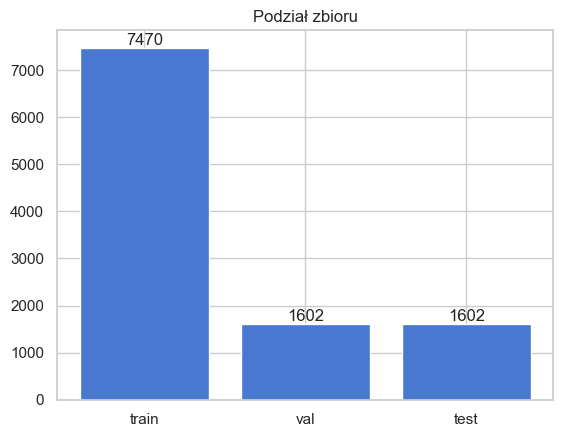

In [76]:
lengths = [len(data_train), len(data_val), len(data_test)]
captions = ["train", "val", "test"]
fig, ax = plt.subplots()
p = ax.bar(captions, lengths)
ax.bar_label(p, label_type="edge")
ax.set_title("Podział zbioru")
plt.show()

In [105]:
masks_flat_train = np.concatenate([np.asarray(item["mask"]).ravel() for item in sample_train])
category_count_train = np.bincount(masks_flat_train.astype(int))

masks_flat_val = np.concatenate([np.asarray(item["mask"]).ravel() for item in sample_val])
category_count_val = np.bincount(masks_flat_val.astype(int))

masks_flat_test = np.concatenate([np.asarray(item["mask"]).ravel() for item in sample_test])
category_count_test = np.bincount(masks_flat_test.astype(int))

<Axes: >

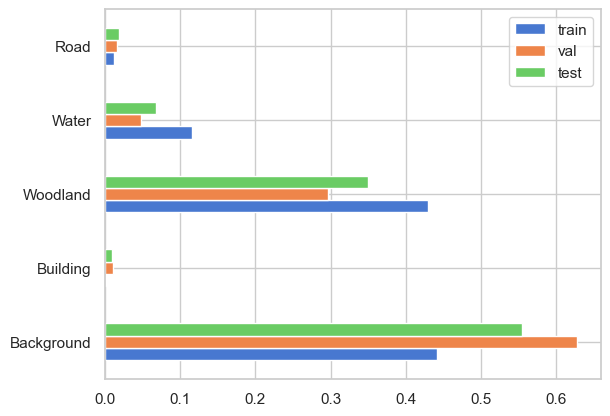

In [108]:
categories = ["Background", "Building", "Woodland", "Water", "Road"]
df = pd.DataFrame({
    'train': category_count_train / len(masks_flat_train),
    'val': category_count_val / len(masks_flat_val),
    'test': category_count_test / len(masks_flat_test)
}, index=categories)

df.plot(kind='barh')

## Przykładowe obrazy


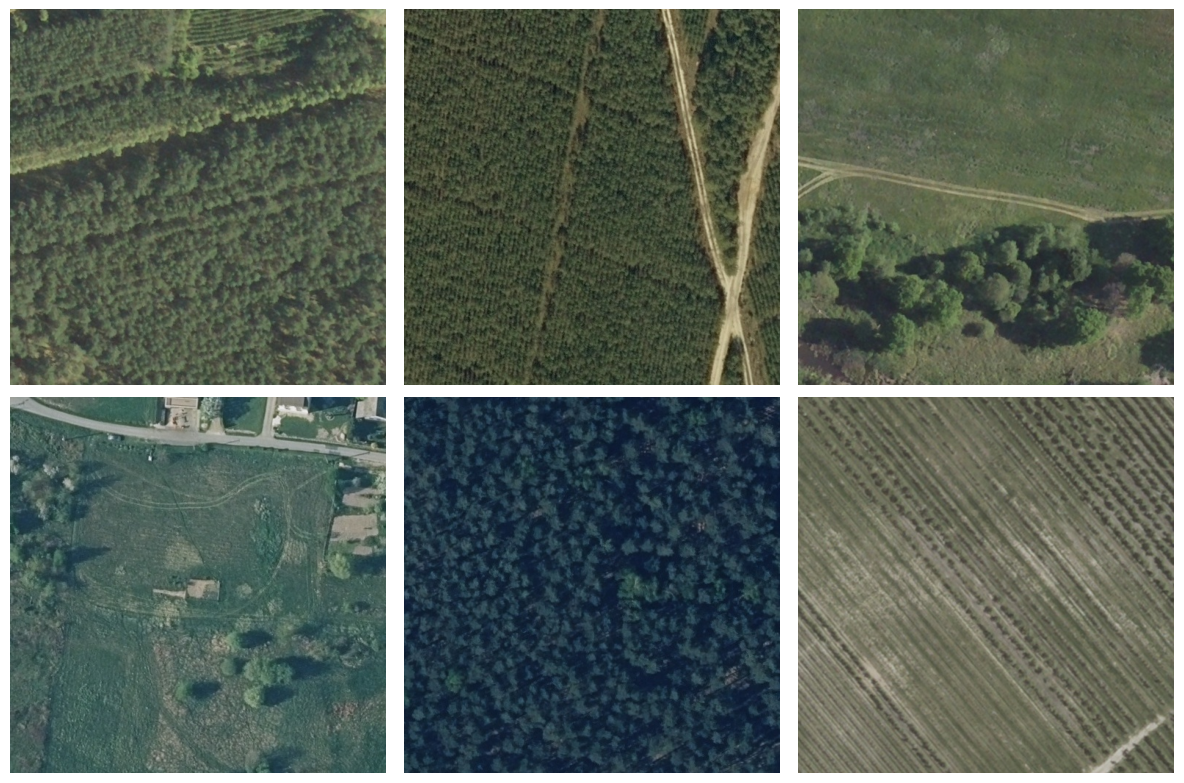

In [ ]:
np.random.seed(1)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
random_pics_id = np.random.randint(0, len(data_val), axes.size)
for i, img_id in enumerate(random_pics_id):
    image = Image.open(data[img_id]["path"])
    axes[i].imshow(image)
    axes[i].axis("off")
plt.tight_layout()
plt.show()

## Średnia i odchylenie standardowe pikseli

In [ ]:
from tqdm import tqdm

mean_acc = np.zeros(3)
var_acc = np.zeros(3)
n = 0

for i in tqdm(range(len(sample_data))):
    image = np.asarray(sample_data[i]["image"])
    mean_acc += image.mean(axis=(1, 2))
    var_acc += image.var(axis=(1, 2))
    n += 1

pixel_mean = mean_acc / n
pixel_std = np.sqrt(var_acc / n)

print(f"Średnia (R, G, B): {pixel_mean}")
print(f"Std     (R, G, B): {pixel_std}")

  0%|          | 0/500 [00:00<?, ?it/s]C:\Users\Mateusz\AppData\Local\Temp\ipykernel_9820\2935143809.py:13: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  image = np.array(sample_data[i]["image"])
100%|██████████| 500/500 [00:03<00:00, 151.60it/s]

Średnia (R, G, B): [0.37451365 0.40184889 0.35060243]
Std    (R, G, B): [0.1159367  0.09916778 0.08508567]


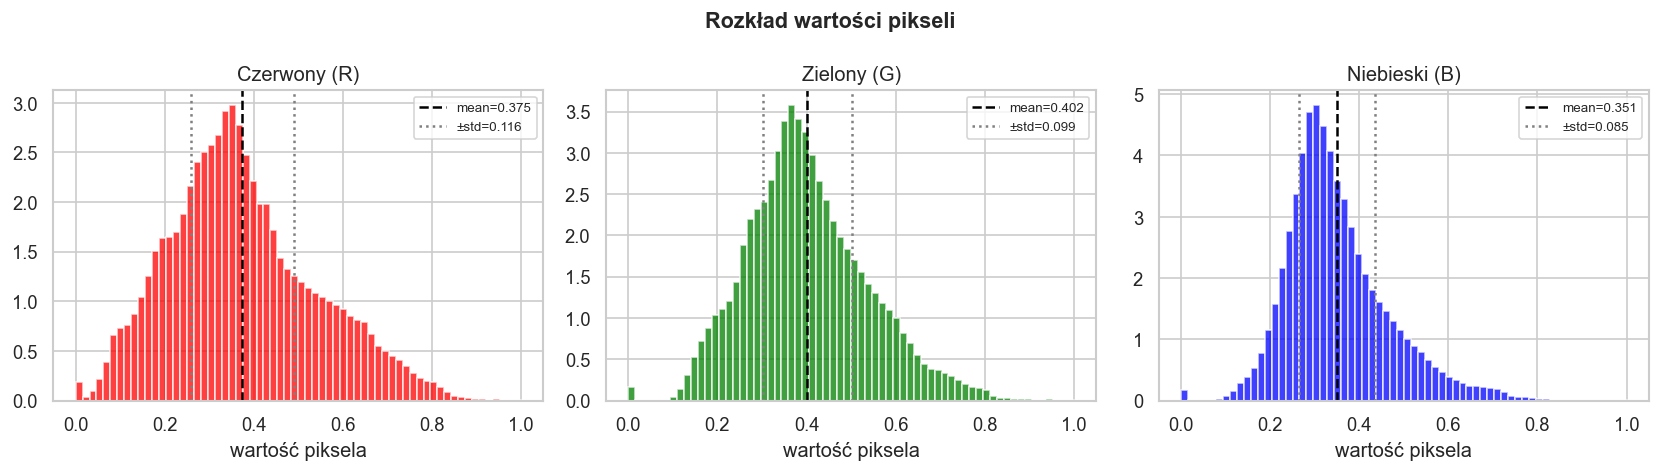

In [61]:
all_images = np.stack([item["image"] for item in sample_data])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(
    "Rozkład wartości pikseli", fontsize=13, fontweight="bold"
)
channel_names = ["Czerwony (R)", "Zielony (G)", "Niebieski (B)"]
colors = ["red", "green", "blue"]

for c, (ax, name, col) in enumerate(zip(axes, channel_names, colors, strict=False)):
    # histogram, bin_edges = np.histogram(all_images[:, c, :, :], bins=64, range=(0, 1))
    ax.hist(all_images[:, c, :, :].ravel(), color=col, bins=64, alpha=0.75, density=True)
    ax.axvline(
        pixel_mean[c], color="black", linestyle="--", label=f"mean={pixel_mean[c]:.3f}"
    )
    ax.axvline(
        pixel_mean[c] + pixel_std[c],
        color="gray",
        linestyle=":",
        label=f"±std={pixel_std[c]:.3f}",
    )
    ax.axvline(pixel_mean[c] - pixel_std[c], color="gray", linestyle=":")
    ax.set_title(name)
    ax.set_xlabel("wartość piksela")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
